# Bluestock Mutual Fund Analytics Platform

## Day 3 - Exploratory Data Analysis (EDA)

### Objective

This notebook performs exploratory data analysis on mutual fund datasets to understand industry growth, fund performance, investor behaviour, SIP trends, portfolio allocation, and fund flow patterns between 2022 and 2026.

### Datasets Used

- Fund Master
- NAV History
- AUM by Fund House
- Monthly SIP Inflows
- Category Inflows
- Industry Folio Count
- Investor Transactions
- Portfolio Holdings

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# Load Data

In [2]:
funds = pd.read_csv("01_fund_master_clean.csv")

nav = pd.read_csv("02_nav_history_clean.csv")

aum = pd.read_csv("03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("05_category_inflows_clean.csv")

folios = pd.read_csv("06_industry_folio_count_clean.csv")

performance = pd.read_csv("07_scheme_performance_clean.csv")

transactions = pd.read_csv("08_investor_transactions_clean.csv")

portfolio = pd.read_csv("09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("10_benchmark_indices_clean.csv")

## Convert date columns

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

aum['date'] = pd.to_datetime(aum['date'])

sip['month'] = pd.to_datetime(sip['month'])

category['month'] = pd.to_datetime(category['month'])

folios['month'] = pd.to_datetime(folios['month'])

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

portfolio['portfolio_date'] = pd.to_datetime(
    portfolio['portfolio_date']
)

# Dataset Overview

Before creating visualisations, the structure and quality of each dataset are examined.

The objective is to:

- Understand dataset dimensions
- Validate available columns
- Check missing values
- Ensure data is ready for analysis

In [4]:
datasets = {
    "Funds": funds,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Transactions": transactions,
    "Portfolio": portfolio
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print("Shape:", df.shape)
    print(df.head())



Funds
Shape: (40, 15)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount

In [5]:
for name, df in datasets.items():
    print("\n",name)
    print(df.isnull().sum())


 Funds
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

 NAV
amfi_code    0
date         0
nav          0
dtype: int64

 AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

 SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

 Category
month               0
category            0
net_inflow_crore    0
dtype: int64

 Folios
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
o

# Missing Value Analysis

Missing value analysis was performed to evaluate data completeness before conducting exploratory analysis.

### Observations

- All datasets are complete with no missing values in critical fields.
- The only missing values were found in the `yoy_growth_pct` column of the SIP dataset.
- These missing values are expected because Year-over-Year growth cannot be calculated for the initial months where prior-year comparison data is unavailable.
- Since the missing values occur in a derived metric and not in the primary SIP inflow values, no imputation was required.

### Conclusion

The datasets are sufficiently complete and suitable for exploratory data analysis.

In [6]:
print("Total Missing Values")

for name, df in datasets.items():
    print(
        f"{name}: {df.isnull().sum().sum()}"
    )

Total Missing Values
Funds: 0
NAV: 0
AUM: 0
SIP: 12
Category: 0
Folios: 0
Transactions: 0
Portfolio: 0


# 1. NAV Trend Analysis (2022–2026)

## Objective

Net Asset Value (NAV) represents the per-unit value of a mutual fund scheme and serves as a key indicator of fund performance.

This analysis examines daily NAV movements across all mutual fund schemes between 2022 and 2026 to identify long-term growth patterns, market rallies, and temporary corrections.

Special focus is given to:

- 2023 Bull Run
- 2024 Market Correction

The analysis helps understand how mutual fund schemes responded to changing market conditions during the study period.

In [7]:
nav_merged = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


## Data Preparation

The NAV dataset contains AMFI codes, dates, and NAV values.

To improve readability of visualisations, scheme names are merged from the fund master dataset using the AMFI scheme code.

In [8]:
print("NAV Dataset Shape:", nav_merged.shape)

nav_merged[['scheme_name','date','nav']].head()

NAV Dataset Shape: (46000, 4)


,scheme_name,date,nav
0,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608
1,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971
2,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239
3,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880
4,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639


## Daily NAV Trends Across All Schemes

The following chart visualises daily NAV movements for all available mutual fund schemes between 2022 and 2026.

Green shaded region highlights the 2023 bull market phase.

Red shaded region highlights the 2024 market correction period.

In [9]:
fig = px.line(
    nav_merged,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trends Across Mutual Fund Schemes (2022–2026)'
)

# 2023 Bull Run
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.12,
    line_width=0,
    annotation_text='2023 Bull Run'
)

# 2024 Correction
fig.add_vrect(
    x0='2024-03-01',
    x1='2024-06-30',
    fillcolor='red',
    opacity=0.12,
    line_width=0,
    annotation_text='2024 Correction'
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='NAV (₹)',
    legend_title='Scheme Name',
    height=700
)

fig.show()
fig.write_html("exported_charts/nav_trend_analysis.html")

## Observations

- Most mutual fund schemes exhibited a positive long-term trend during the analysis period.
- NAV growth accelerated significantly during the 2023 bull market.
- A temporary decline or slowdown was visible during the 2024 correction phase.
- Despite short-term volatility, most schemes recovered and continued their upward trajectory.

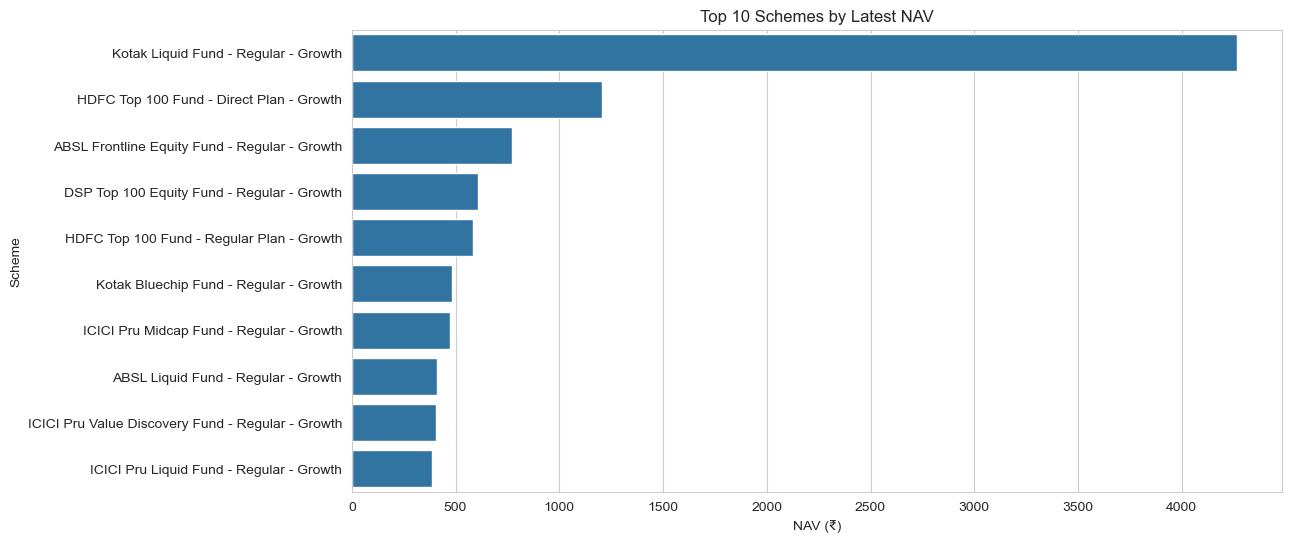

In [10]:
latest_nav = (
    nav_merged
    .sort_values('date')
    .groupby('scheme_name')
    .tail(1)
    .sort_values('nav', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_nav,
    x='nav',
    y='scheme_name'
)

plt.title('Top 10 Schemes by Latest NAV')
plt.xlabel('NAV (₹)')
plt.ylabel('Scheme')

plt.show()
fig.write_html("exported_charts/nav_trend_analysis.html")

### Key Insight

The NAV analysis indicates strong long-term growth across most mutual fund schemes. Market-wide appreciation during 2023 contributed significantly to NAV expansion, while the 2024 correction introduced short-term volatility without disrupting the overall growth trend.

# 2. Assets Under Management (AUM) Growth Analysis

## Objective

Assets Under Management (AUM) represents the total market value of investments managed by a fund house.

AUM is one of the most important indicators of the size, market presence, and investor trust in an Asset Management Company (AMC).

This analysis evaluates:

- Annual AUM growth from 2022 to 2025
- Performance comparison across fund houses
- Market leadership among AMCs
- SBI Mutual Fund's dominance in the industry

In [11]:
# Check AUM dataset

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


## Data Preparation

The AUM dataset contains yearly AUM values for multiple fund houses.

For comparison purposes, the year is extracted from the date column and maximum annual AUM is used.

In [12]:
# Extract year

aum['year'] = aum['date'].dt.year

aum_year = (
    aum.groupby(['year', 'fund_house'])['aum_lakh_crore']
    .max()
    .reset_index()
)

aum_year.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.85
1,2022,Axis Mutual Fund,2.50
2,2022,DSP Mutual Fund,1.12
3,2022,HDFC Mutual Fund,4.45
4,2022,ICICI Prudential MF,4.88


## AUM Growth by Fund House

The following grouped bar chart compares Assets Under Management (AUM) across fund houses from 2022 to 2025.

AUM values are represented in lakh crore rupees.

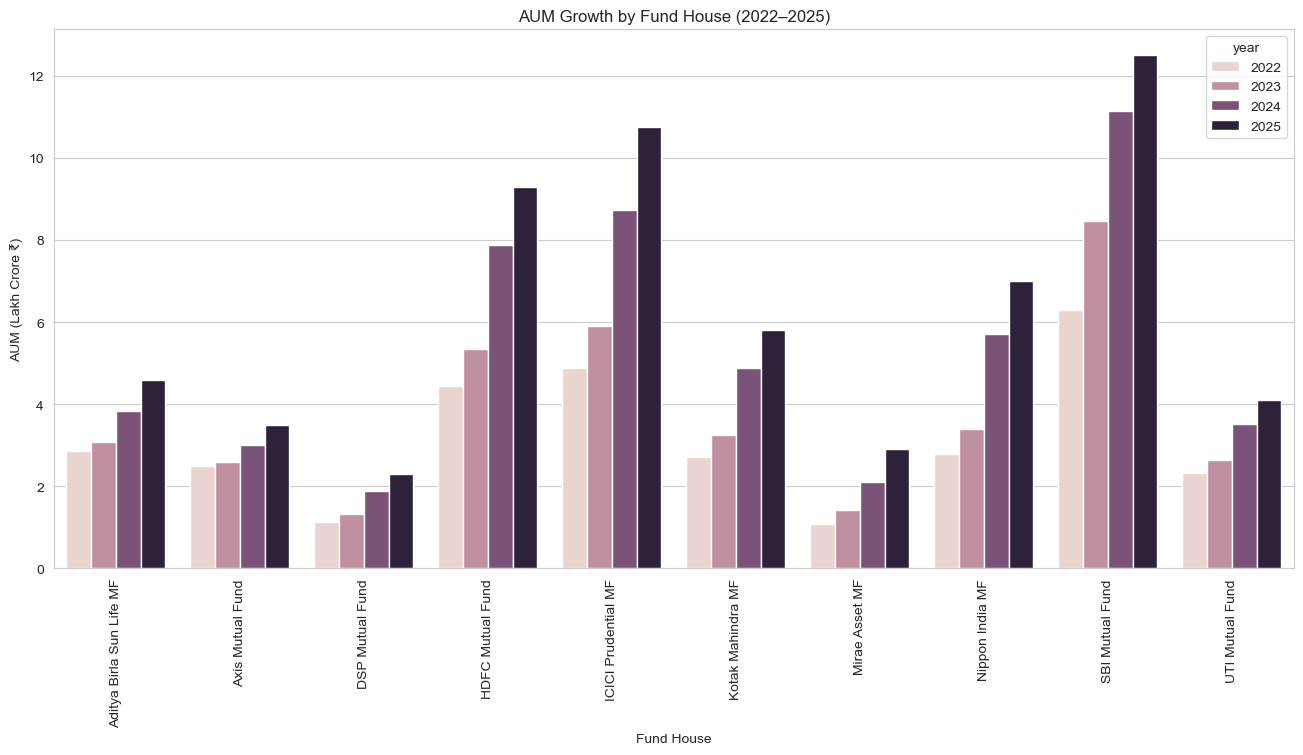

In [13]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=aum_year,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year'
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore ₹)')
plt.xticks(rotation=90)

plt.savefig(
    "exported_charts/aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations

- AUM increased across most fund houses during the study period.
- Industry growth remained strong between 2022 and 2025.
- Larger AMCs maintained a significant lead over smaller competitors.
- Market concentration remains visible among top fund houses.

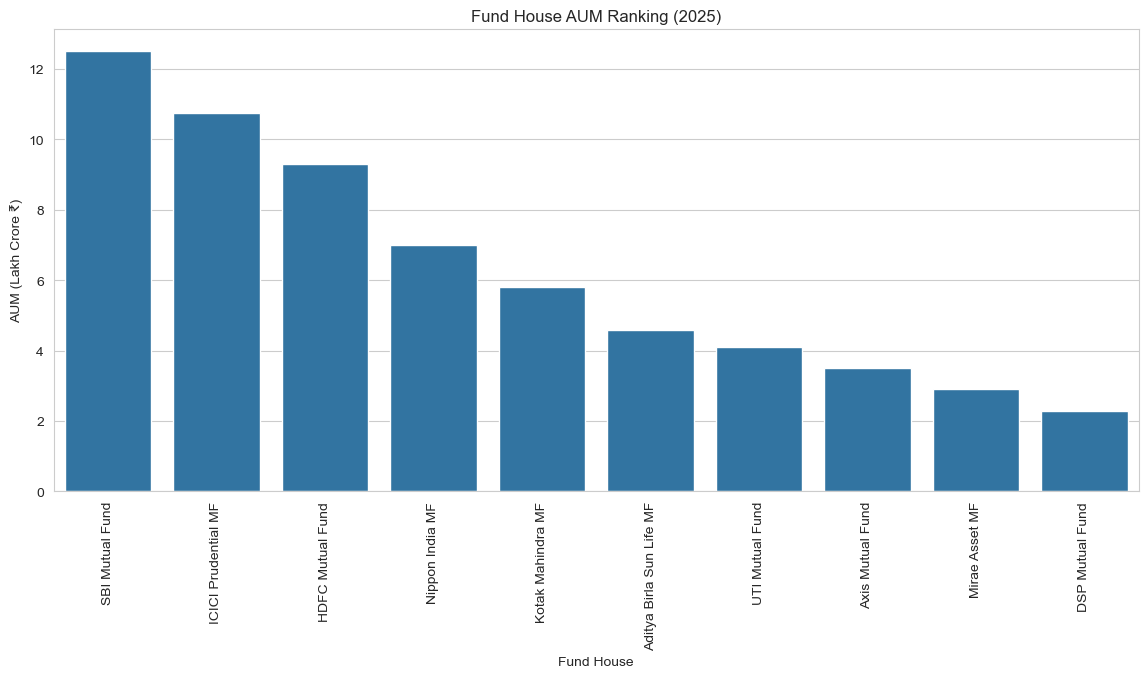

In [14]:
latest_year = aum_year['year'].max()

latest_aum = (
    aum_year[aum_year['year'] == latest_year]
    .sort_values('aum_lakh_crore', ascending=False)
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=latest_aum,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.title(f'Fund House AUM Ranking ({latest_year})')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore ₹)')
plt.xticks(rotation=90)

plt.show()

In [15]:
sbi_aum = latest_aum[
    latest_aum['fund_house']
    .str.contains('SBI', case=False)
]

sbi_aum

,year,fund_house,aum_lakh_crore
38,2025,SBI Mutual Fund,12.5


## SBI Mutual Fund Leadership

SBI Mutual Fund remained the largest AMC in the dataset and managed approximately ₹12.5 lakh crore of assets.

Its AUM significantly exceeded many competing fund houses, highlighting its dominant position within the Indian mutual fund industry.

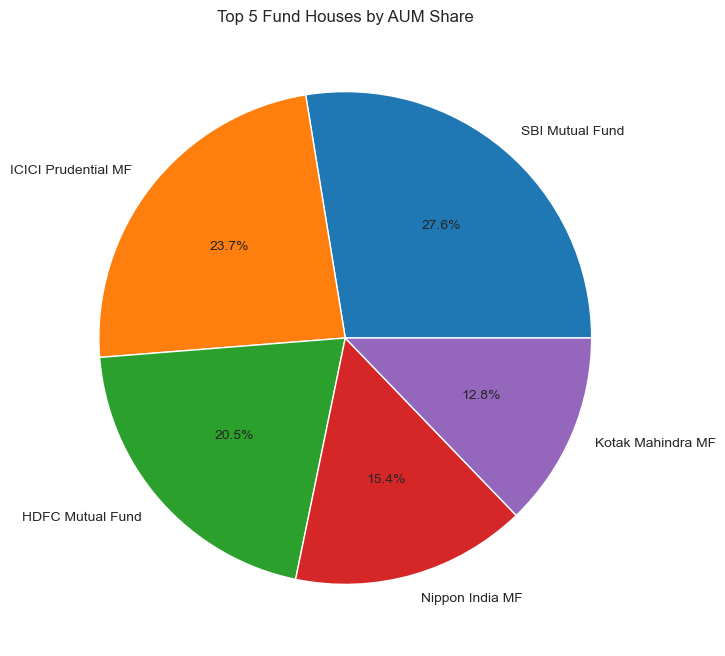

In [16]:
top5 = latest_aum.head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5['aum_lakh_crore'],
    labels=top5['fund_house'],
    autopct='%1.1f%%'
)

plt.title('Top 5 Fund Houses by AUM Share')

plt.show()

### Key Insight

The AUM analysis highlights sustained growth in the mutual fund industry. SBI Mutual Fund emerged as the industry leader, maintaining the highest AUM throughout the analysis period and reinforcing its dominant market position.

# 3. SIP Inflow Trend Analysis

## Objective

Systematic Investment Plans (SIPs) represent one of the most important investment channels for retail mutual fund investors.

SIP inflows provide insights into investor confidence, market participation, and long-term investment behaviour.

This analysis examines monthly SIP inflows from January 2022 to December 2025 to identify growth trends and significant milestones.

Special focus is given to the record SIP inflow achieved in December 2025.

In [17]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


## Data Overview

The SIP dataset contains:

- Monthly SIP inflows
- Active SIP accounts
- New SIP registrations
- SIP Assets Under Management (AUM)
- Year-over-Year growth metrics

The primary metric analysed in this section is monthly SIP inflow measured in crore rupees.
    

In [18]:
print("Date Range:")
print(sip['month'].min())
print(sip['month'].max())

print("\nDataset Shape:")
print(sip.shape)


Date Range:
2022-01-01 00:00:00
2025-12-01 00:00:00

Dataset Shape:
(48, 6)


## Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)

The following Plotly time-series chart visualises monthly SIP inflows over the analysis period.

The highest SIP inflow recorded during the study period is highlighted and annotated.
    

In [19]:
max_row = sip.loc[
    sip['sip_inflow_crore'].idxmax()
]

max_row

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [20]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)'
)

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    height=600
)

fig.show()
fig.write_html("exported_charts/sip_inflow_trend.html")

## Observations

- SIP inflows exhibited a strong upward trend throughout the study period.
- Retail participation increased consistently between 2022 and 2025.
- Periodic fluctuations were observed; however, the long-term direction remained positive.
- December 2025 recorded the highest SIP inflow during the analysis period.

## Growth in Active SIP Accounts

Increasing active SIP accounts indicate expanding investor participation and stronger adoption of systematic investing.

In [21]:
fig = px.line(
    sip,
    x='month',
    y='active_sip_accounts_crore',
    markers=True,
    title='Active SIP Accounts Growth'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Active SIP Accounts (Crore)'
)

fig.show()
fig.write_html("exported_charts/sip_inflow_trend.html")

## SIP Assets Under Management (AUM)

SIP AUM reflects the cumulative assets accumulated through SIP investments and serves as an indicator of long-term investor commitment.

In [22]:
fig = px.line(
    sip,
    x='month',
    y='sip_aum_lakh_crore',
    markers=True,
    title='SIP Assets Under Management Growth'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP AUM (Lakh Crore ₹)'
)

fig.show()
fig.write_html("exported_charts/sip_inflow_trend.html")

### Key Insight

Monthly SIP inflows demonstrated sustained growth throughout the analysis period, reflecting increasing investor confidence in mutual funds.

The industry achieved a historic milestone in December 2025 when monthly SIP inflows reached approximately ₹31,002 crore, marking the highest inflow observed during the study period.

In [23]:
fig.write_html("sip_inflow_trend.html")

# 4. Category Inflow Heatmap

## Objective

Mutual fund investors allocate capital across different fund categories based on market conditions, risk appetite, and investment objectives.

This analysis examines category-wise net inflows over time to identify investor preferences and periods of strong fund flow activity.

The heatmap uses:

- Months on the X-axis
- Fund categories on the Y-axis
- Net inflow values as colour intensity

Higher colour intensity represents stronger inflows into a category during a particular month.

In [24]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


## Dataset Overview

The category inflow dataset contains:

- Month
- Fund Category
- Net Inflow (₹ Crore)

Before creating the heatmap, the dataset is transformed into a matrix format suitable for visualization.

In [25]:
print("Shape:", category.shape)

category.sample(5)

Shape: (144, 3)


,month,category,net_inflow_crore
22,2024-05-01,Gilt,836.0
42,2024-07-01,Value/Contra,1582.0
59,2024-08-01,Hybrid,3684.0
90,2024-11-01,Value/Contra,1436.0
115,2025-01-01,Sectoral/Thematic,7893.0


## Data Preparation

For heatmap visualization:

- Rows represent mutual fund categories
- Columns represent months
- Values represent net inflows in crore rupees

This structure allows easy comparison of inflow patterns across categories and time periods.

In [26]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


## Category-wise Net Inflow Heatmap

The following heatmap visualizes monthly inflows across all mutual fund categories.

Darker shades indicate stronger inflows while lighter shades indicate relatively lower inflows.

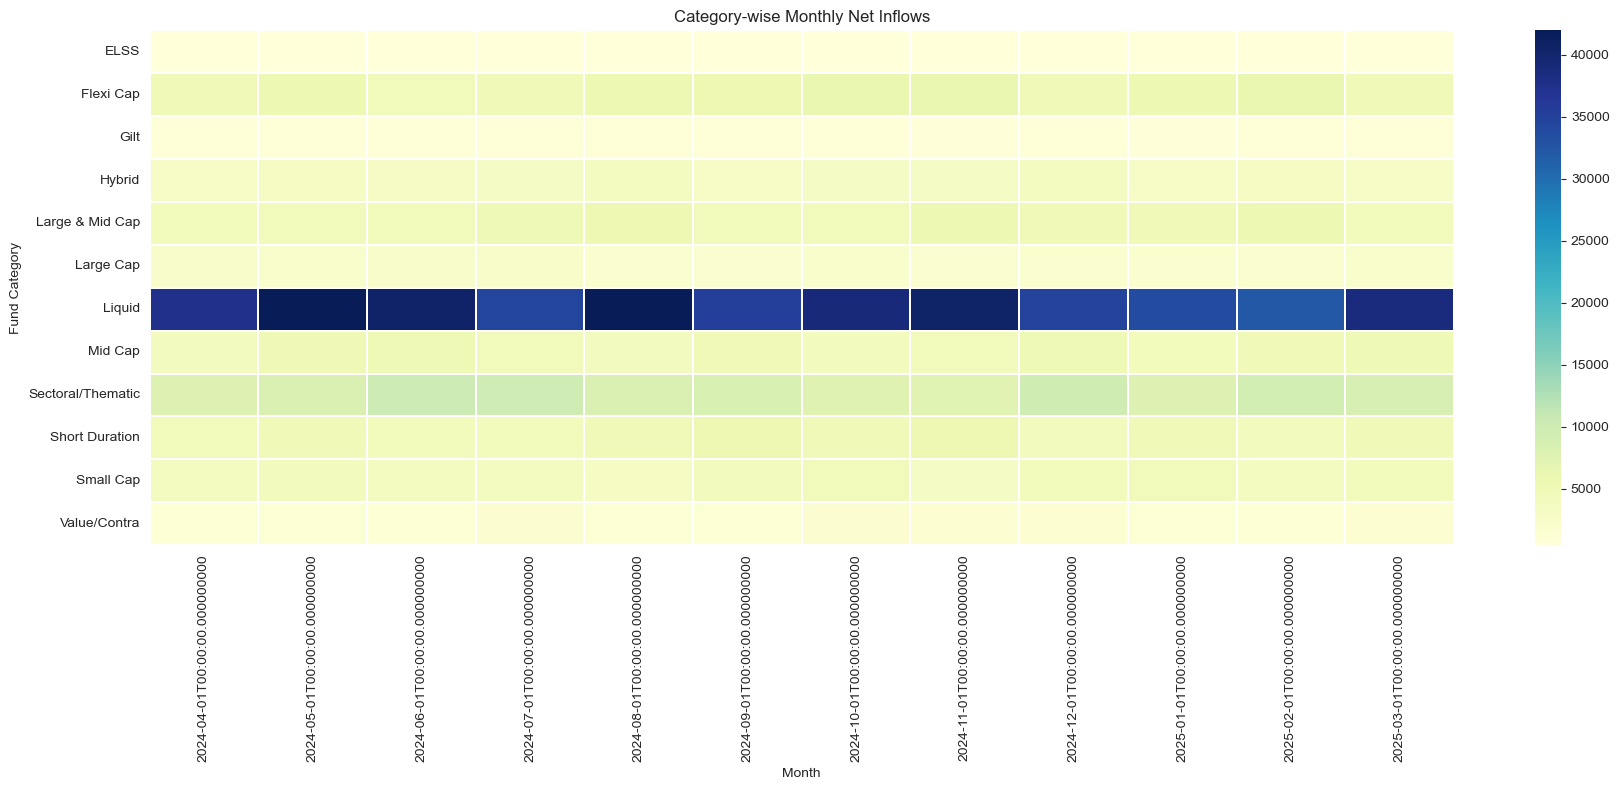

In [27]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.3
)

plt.title(
    'Category-wise Monthly Net Inflows'
)

plt.xlabel('Month')

plt.ylabel('Fund Category')

plt.tight_layout()

plt.savefig(
    "exported_charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations

- Certain categories consistently attracted stronger inflows throughout the analysis period.
- Investor demand varied across categories depending on market conditions.
- Some categories experienced periodic spikes in inflows during favourable market environments.
- Fund flow activity was concentrated in a limited number of categories.

## Total Net Inflow by Category

This chart aggregates net inflows across the entire analysis period and identifies the most preferred mutual fund categories.

In [28]:
category_total = (
    category.groupby('category')['net_inflow_crore']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_total.head()

,category,net_inflow_crore
0,Liquid,451275.0
1,Sectoral/Thematic,103829.0
2,Flexi Cap,63989.0
3,Large & Mid Cap,57752.0
4,Short Duration,55530.0


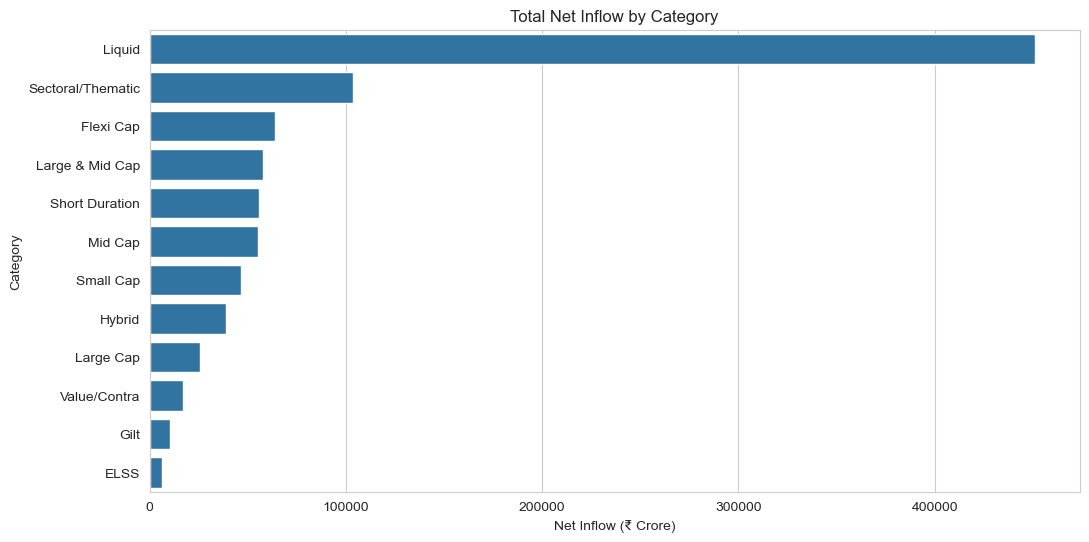

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_total,
    x='net_inflow_crore',
    y='category'
)

plt.title(
    'Total Net Inflow by Category'
)

plt.xlabel('Net Inflow (₹ Crore)')

plt.ylabel('Category')

plt.show()

## Top 10 Categories by Net Inflow

The following chart highlights the ten categories that received the highest cumulative inflows during the study period.

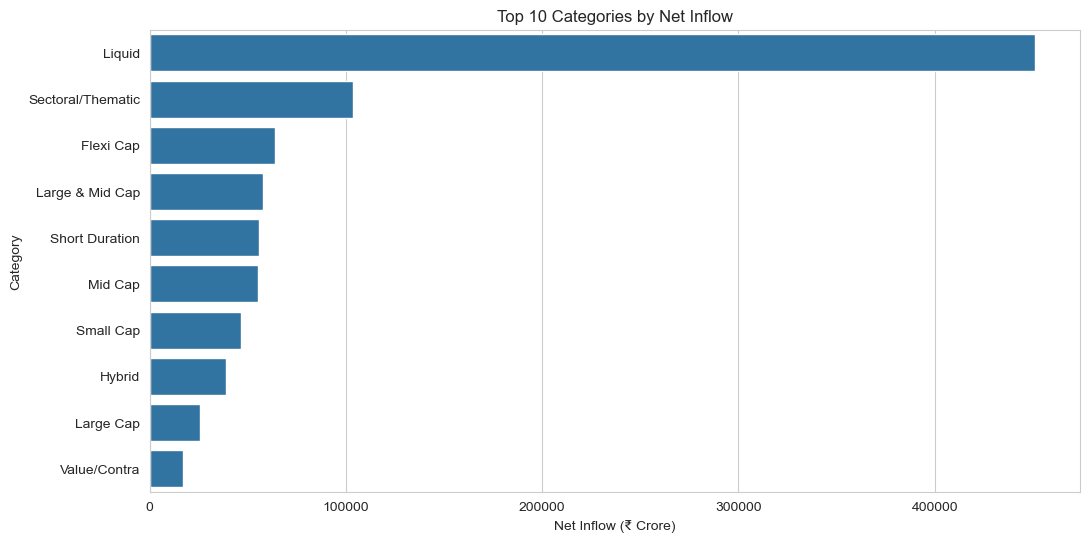

In [30]:
top10_categories = category_total.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_categories,
    x='net_inflow_crore',
    y='category'
)

plt.title(
    'Top 10 Categories by Net Inflow'
)

plt.xlabel('Net Inflow (₹ Crore)')

plt.ylabel('Category')

plt.show()

### Key Insight

The category inflow analysis reveals that investor interest is concentrated in a relatively small number of mutual fund categories. These categories consistently attracted higher net inflows, indicating stronger investor preference and confidence throughout the analysis period.


# 5. Investor Demographics Analysis

## Objective

Investor demographics provide insights into the characteristics of mutual fund investors and help identify the segments driving industry growth.

This analysis focuses on:

- Age group distribution of investors
- SIP investment behaviour across age groups
- Gender-wise investor participation

Understanding demographic trends helps asset management companies design targeted investment products and marketing strategies.

In [31]:
transactions

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32773,INV003340,2025-05-30,101207,LUMPSUM,168029,Madhya Pradesh,Indore,T30,26-35,Male,22.5,Net Banking,Verified
32774,INV001838,2025-05-30,119093,SIP,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified
32775,INV000074,2025-05-30,120504,SIP,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified
32776,INV002929,2025-05-30,148568,SIP,459,West Bengal,Kolkata,T30,26-35,Male,13.0,Mandate,Verified


## Dataset Overview

The investor transactions dataset contains demographic information including:

- Age Group
- Gender
- State
- City Tier
- Investment Amount
- Transaction Type

These attributes are used to analyze investor participation patterns.

In [32]:
print("Total Investors :", transactions['investor_id'].nunique())

print("\nAge Groups")
print(transactions['age_group'].value_counts())

print("\nGender Distribution")
print(transactions['gender'].value_counts())

Total Investors : 5000

Age Groups
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender Distribution
gender
Male      21809
Female    10969
Name: count, dtype: int64


## Age Group Distribution

The following chart shows the proportion of investors across different age groups.

This helps identify which age segments contribute most to mutual fund participation.


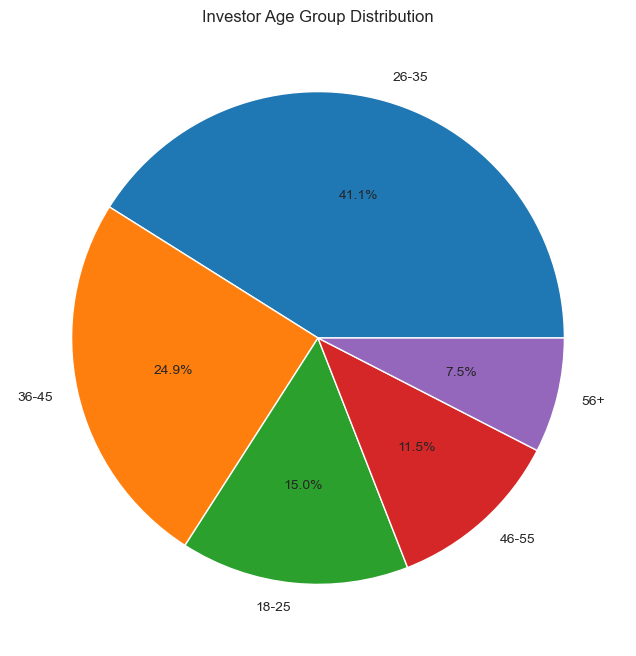

In [33]:
age_counts = transactions['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')
plt.savefig(
    "exported_charts/investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observations

- Certain age groups contribute a larger share of investors.
- Working-age investors generally dominate mutual fund participation.
- Younger investors indicate increasing awareness of long-term investing.

## SIP Amount Distribution by Age Group

This analysis compares SIP investment amounts across age groups.

A box plot is used to visualize:

- Median SIP amount
- Interquartile range
- Investment variability
- Outliers

In [34]:
sip_txn = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
]

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


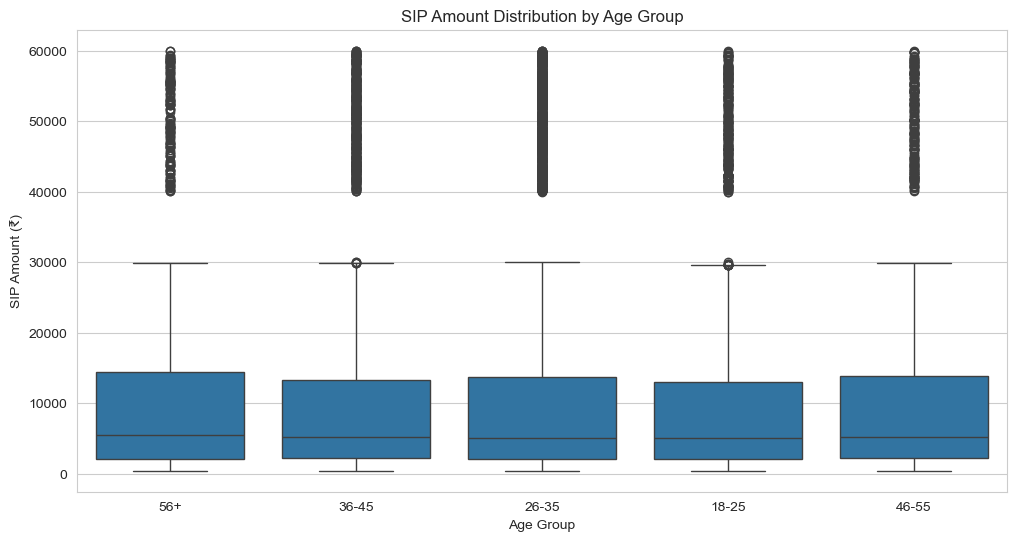

In [35]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x='age_group',
    y='amount_inr'
)

plt.title('SIP Amount Distribution by Age Group')

plt.xlabel('Age Group')

plt.ylabel('SIP Amount (₹)')

plt.show()

## Observations

- Median SIP amounts vary across age groups.
- Older investors may exhibit higher investment capacity.
- The presence of outliers indicates investors making significantly larger SIP contributions.

## Gender-wise Investor Participation

The following chart shows the distribution of investors by gender.

This helps understand the level of participation across demographic groups.


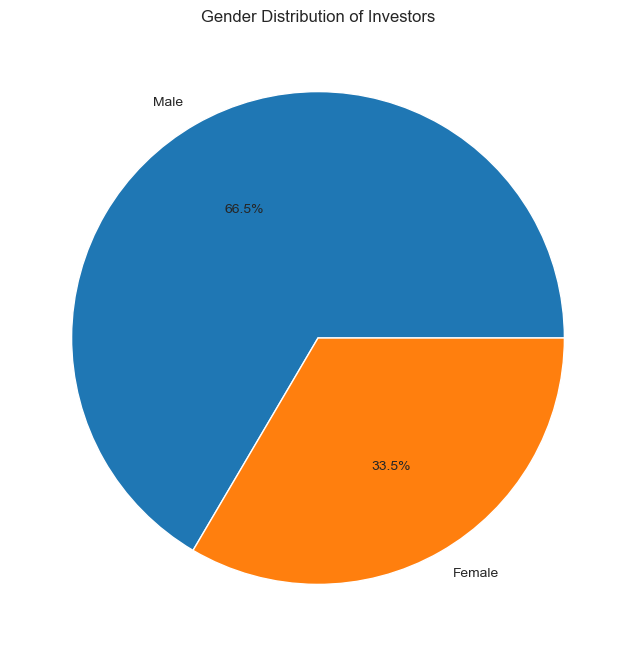

In [36]:
gender_counts = transactions['gender'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Investors')


plt.savefig(
    "exported_charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observations

- Both genders actively participate in mutual fund investing.
- The distribution highlights the relative contribution of each gender to the investor base.
- Increasing diversity in participation reflects broader financial inclusion.

## Average Investment Amount by Age Group

This chart compares the average transaction amount across different age groups.

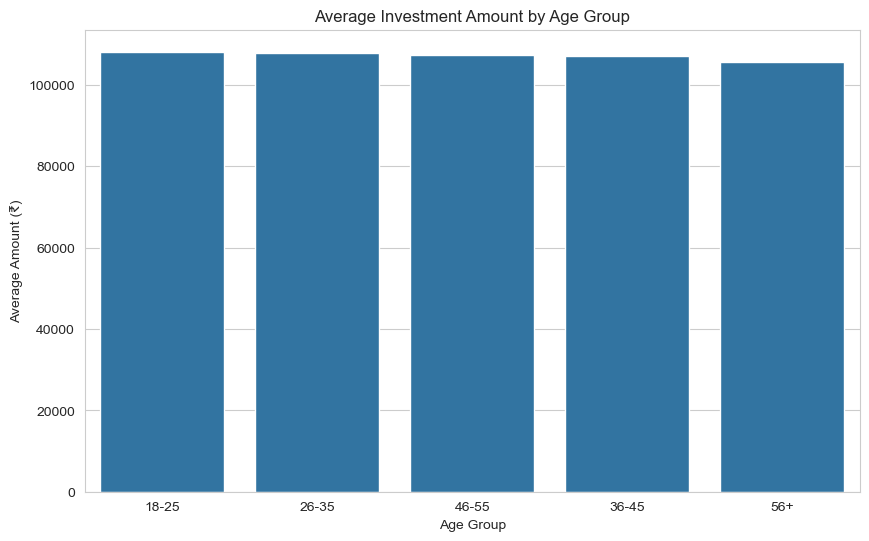

In [37]:
avg_age = (
    transactions.groupby('age_group')['amount_inr']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_age,
    x='age_group',
    y='amount_inr'
)

plt.title('Average Investment Amount by Age Group')

plt.xlabel('Age Group')

plt.ylabel('Average Amount (₹)')


plt.savefig(
    "exported_charts/sip_amount_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [38]:
transactions.groupby('age_group')['amount_inr'].mean()

age_group
18-25    108144.709520
26-35    107821.452722
36-45    107003.133808
46-55    107278.769251
56+      105613.105497
Name: amount_inr, dtype: float64

### Key Insight

Investor participation is concentrated among working-age groups, while SIP investment amounts vary across age segments. Gender participation remains broadly distributed, reflecting growing adoption of mutual fund investing across different demographic groups.

# 6. Geographic Distribution Analysis

## Objective

Geographic analysis helps identify the regions contributing the highest investment volumes and provides insights into the spread of mutual fund adoption across India.

This section evaluates:

- State-wise SIP investment contribution
- Participation across T30 and B30 city categories

Understanding geographic patterns helps identify areas with strong investor activity and potential growth opportunities.

In [39]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


## Dataset Overview

The investor transaction dataset contains location-related information including:

- State
- City
- City Tier (T30 / B30)
- Transaction Amount

These attributes are used to analyze geographic investment patterns.


In [40]:
print("Number of States:",
      transactions['state'].nunique())

print("\nCity Tier Distribution")
print(transactions['city_tier'].value_counts())

Number of States: 12

City Tier Distribution
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


## State-wise SIP Contribution

The following chart shows total SIP investment amounts aggregated by state.

A horizontal bar chart is used to improve readability when comparing multiple states.

In [41]:
sip_transactions = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
]

In [42]:
state_sip = (
    sip_transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

state_sip.head()

state
Maharashtra      16445629
Rajasthan        16544233
Delhi            17113608
West Bengal      17495769
Uttar Pradesh    17534858
Name: amount_inr, dtype: int64

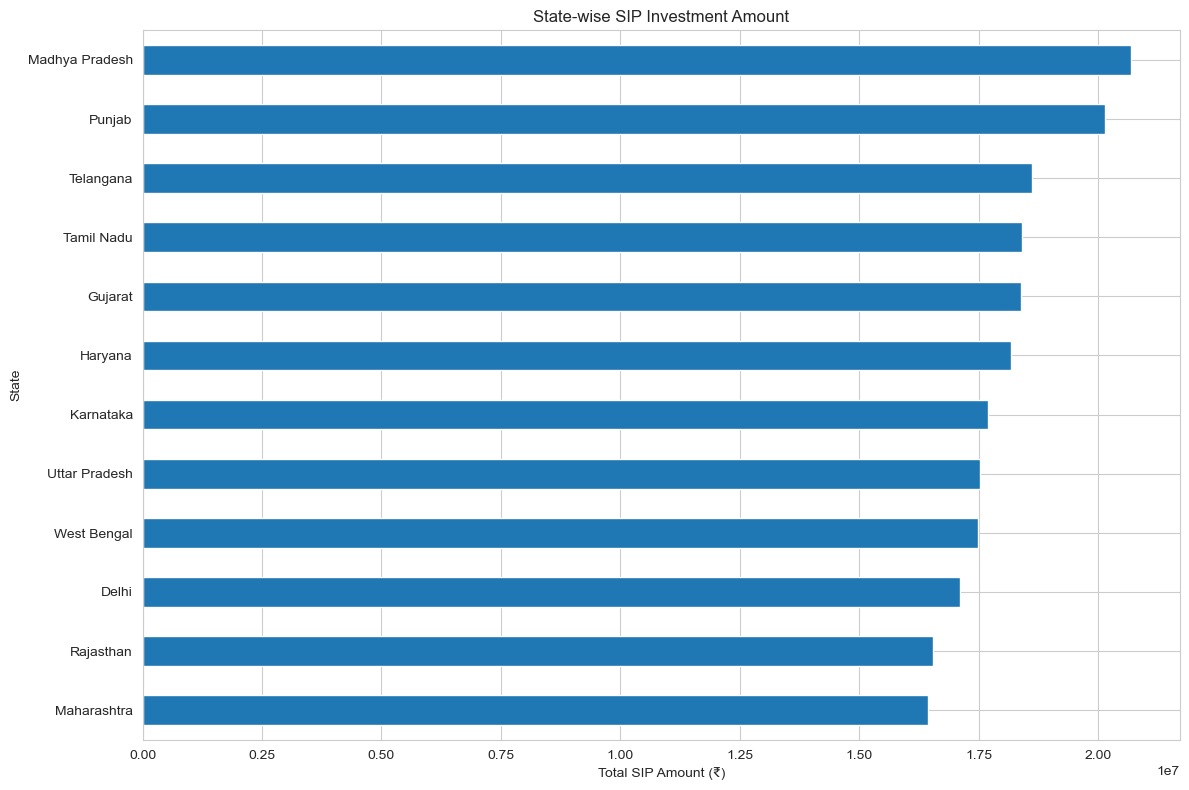

In [43]:
plt.figure(figsize=(12,8))

state_sip.plot(
    kind='barh'
)

plt.title(
    'State-wise SIP Investment Amount'
)

plt.xlabel('Total SIP Amount (₹)')

plt.ylabel('State')

plt.tight_layout()
plt.savefig(
    "exported_charts/state_wise_investment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observations

- Investment activity varies significantly across states.
- A small number of states account for a large share of SIP investments.
- States with stronger financial participation contribute higher cumulative investment amounts.

## Top 10 States by SIP Investment

The following chart highlights the states contributing the highest total SIP investment amounts.

In [44]:
top_states = (
    sip_transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_states

,state,amount_inr
0,Madhya Pradesh,20682243
1,Punjab,20140064
2,Telangana,18620216
3,Tamil Nadu,18404368
4,Gujarat,18378904
5,Haryana,18176696
6,Karnataka,17696903
7,Uttar Pradesh,17534858
8,West Bengal,17495769
9,Delhi,17113608


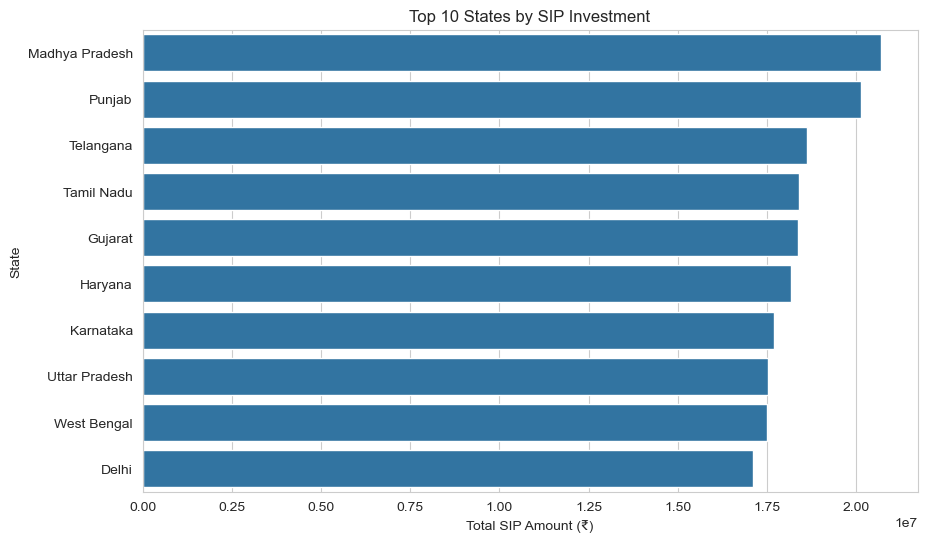

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states,
    x='amount_inr',
    y='state'
)

plt.title(
    'Top 10 States by SIP Investment'
)

plt.xlabel('Total SIP Amount (₹)')

plt.ylabel('State')
plt.savefig(
    "exported_charts/state_wise_investment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## T30 vs B30 City Tier Distribution

T30 cities represent the top 30 cities by mutual fund penetration, while B30 cities represent all other cities.

The following chart compares investor participation across these two categories.

In [46]:
city_tier_counts = (
    transactions['city_tier']
    .value_counts()
)

city_tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

In [47]:
city_tier_counts = (
    transactions['city_tier']
    .value_counts()
)

city_tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

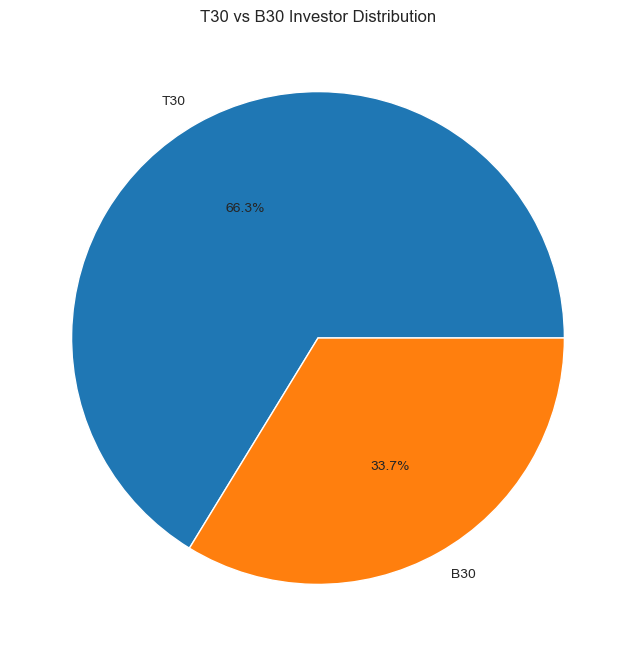

In [48]:
plt.figure(figsize=(8,8))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    'T30 vs B30 Investor Distribution'
)
plt.savefig(
    "exported_charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## SIP Investment Amount by City Tier

The following chart compares total SIP investment amounts originating from T30 and B30 cities.

In [49]:
tier_amount = (
    sip_transactions
    .groupby('city_tier')['amount_inr']
    .sum()
    .reset_index()
)

tier_amount

,city_tier,amount_inr
0,B30,72304870
1,T30,144928621


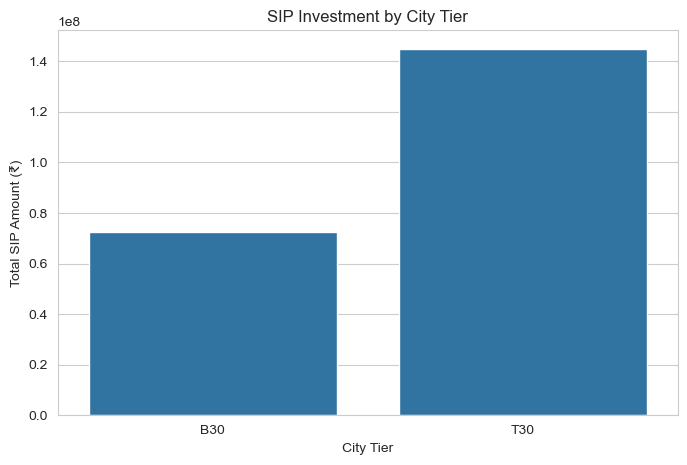

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tier_amount,
    x='city_tier',
    y='amount_inr'
)

plt.title(
    'SIP Investment by City Tier'
)

plt.xlabel('City Tier')

plt.ylabel('Total SIP Amount (₹)')

plt.show()

### Key Insight

Geographic analysis reveals that mutual fund participation is concentrated in a limited number of states and urban centers. T30 cities contribute a substantial share of investment activity, although B30 cities also represent an important and growing investor segment.

# 7. Folio Count Growth Analysis

## Objective

A folio represents an investor account in the mutual fund industry.

Growth in folio count is an important indicator of investor participation and industry expansion.

This analysis examines the growth of total mutual fund folios from January 2022 to December 2025 and identifies major milestones achieved during the period.

In [51]:
folios.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


## Dataset Overview

The folio dataset contains monthly counts for:

- Total Industry Folios
- Equity Folios
- Debt Folios
- Hybrid Folios
- Other Category Folios

The primary focus of this section is total industry folio growth.
    

In [52]:
print("Date Range:")
print(folios['month'].min())
print(folios['month'].max())

print("\nDataset Shape:")
print(folios.shape)

Date Range:
2022-01-01 00:00:00
2025-12-01 00:00:00

Dataset Shape:
(21, 6)


## Total Folio Growth Trend

The following chart visualizes the growth in total mutual fund folios over the analysis period.

Important milestones are highlighted to demonstrate increasing investor participation.

In [53]:
start_folio = folios.iloc[0]
end_folio = folios.iloc[-1]

start_folio

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object

In [54]:
end_folio

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [55]:
fig = px.line(
    folios,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Growth in Mutual Fund Folios (2022–2025)'
)

fig.add_annotation(
    x=start_folio['month'],
    y=start_folio['total_folios_crore'],
    text=f"Start: {start_folio['total_folios_crore']:.2f} Cr",
    showarrow=True
)

fig.add_annotation(
    x=end_folio['month'],
    y=end_folio['total_folios_crore'],
    text=f"End: {end_folio['total_folios_crore']:.2f} Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)',
    height=600
)
plt.savefig(
    "exported_charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)
fig.show()


<Figure size 1200x600 with 0 Axes>

## Observations

- Total folio count increased consistently throughout the analysis period.
- Investor participation expanded significantly between 2022 and 2025.
- The industry successfully doubled its folio base over the study period.

## Growth by Folio Category

The following chart compares the growth of different folio categories over time.

In [56]:
fig = px.line(
    folios,
    x='month',
    y=[
        'equity_folios_crore',
        'debt_folios_crore',
        'hybrid_folios_crore',
        'others_folios_crore'
    ],
    title='Folio Growth by Category'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Folios (Crore)'
)

fig.show()

## Equity Folio Growth

Equity folios typically represent the largest share of mutual fund investor participation.

The following chart tracks equity folio growth over time.

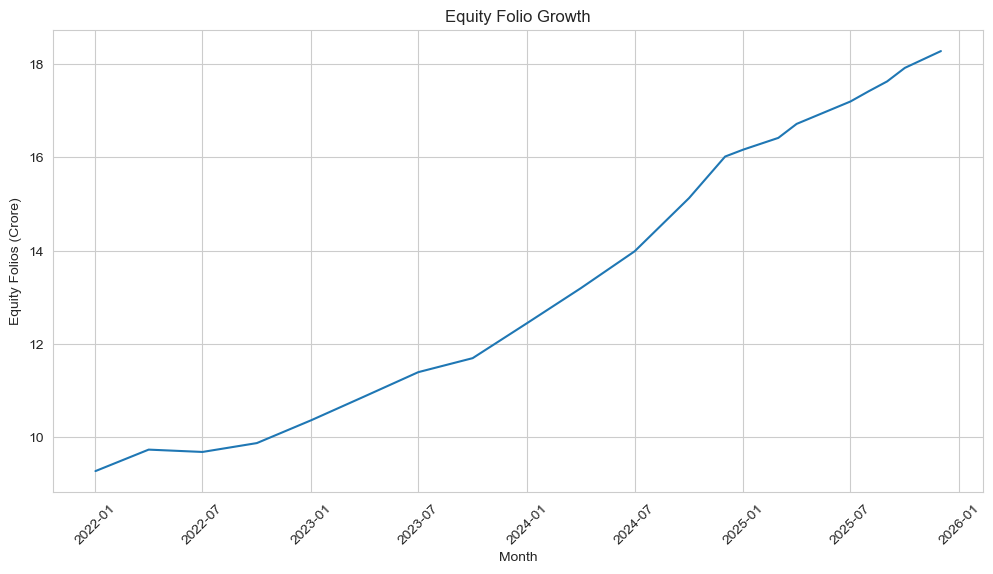

In [57]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=folios,
    x='month',
    y='equity_folios_crore'
)

plt.title('Equity Folio Growth')

plt.xlabel('Month')

plt.ylabel('Equity Folios (Crore)')

plt.xticks(rotation=45)

plt.show()

### Key Insight

The mutual fund industry experienced strong expansion between 2022 and 2025, with total folios increasing from approximately 13.26 crore to 26.12 crore. This reflects sustained investor participation and growing adoption of mutual fund investments across the country.

In [58]:
folios.iloc[0]['total_folios_crore']

np.float64(13.26)

In [59]:
folios.iloc[-1]['total_folios_crore']

np.float64(26.12)

# 8. NAV Return Correlation Matrix

## Objective

Correlation analysis helps identify the degree to which mutual fund schemes move together.

Highly correlated funds tend to exhibit similar return patterns, while low correlation may indicate diversification benefits.

This analysis computes pairwise correlations of daily NAV returns for ten selected mutual fund schemes.

In [60]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Data Preparation

Daily NAV values are converted into percentage returns.

Correlation is computed using daily returns rather than raw NAV values because return-based analysis better captures relationships between fund performance.

In [61]:
selected_funds = nav['amfi_code'].unique()[:10]

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [62]:
nav_10 = nav[
    nav['amfi_code'].isin(selected_funds)
].copy()

nav_10.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [63]:
nav_10['date'] = pd.to_datetime(
    nav_10['date']
)

nav_10 = nav_10.sort_values(
    ['amfi_code','date']
)

## Creating NAV Matrix

The dataset is reshaped into a matrix where:

- Rows represent dates
- Columns represent mutual fund schemes
- Values represent NAV

In [64]:
nav_matrix = nav_10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

nav_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [65]:
full_dates = pd.date_range(
    nav_matrix.index.min(),
    nav_matrix.index.max(),
    freq='D'
)

nav_matrix = nav_matrix.reindex(
    full_dates
).ffill()

## Daily Return Calculation

Daily returns are computed using percentage change in NAV values.

In [66]:
returns = nav_matrix.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [67]:
returns = returns.dropna()

## Correlation Matrix

The following matrix measures pairwise correlation between fund returns.

Values closer to:

- +1 indicate strong positive correlation
- 0 indicate weak correlation
- -1 indicate inverse relationship

In [68]:
corr_matrix = returns.corr()

corr_matrix


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045839,0.000393,0.028120,0.016166,-0.028215,-0.093070,-0.005824,-0.023015,-0.026317
100025,0.045839,1.000000,0.003928,0.025551,-0.006190,0.030928,0.000605,0.013934,-0.004360,-0.012227
100033,0.000393,0.003928,1.000000,-0.015645,0.001025,0.025385,-0.032006,-0.017897,-0.034907,-0.010785
101206,0.028120,0.025551,-0.015645,1.000000,0.010879,-0.006652,0.003769,0.007474,-0.004760,-0.002855
101207,0.016166,-0.006190,0.001025,0.010879,1.000000,-0.001751,-0.005302,0.004931,0.002786,0.044044
101208,-0.028215,0.030928,0.025385,-0.006652,-0.001751,1.000000,0.015346,0.015188,0.046870,0.022659
102885,-0.093070,0.000605,-0.032006,0.003769,-0.005302,0.015346,1.000000,0.020899,-0.035102,0.002019
102886,-0.005824,0.013934,-0.017897,0.007474,0.004931,0.015188,0.020899,1.000000,-0.007682,-0.039566
102887,-0.023015,-0.004360,-0.034907,-0.004760,0.002786,0.046870,-0.035102,-0.007682,1.000000,0.003043


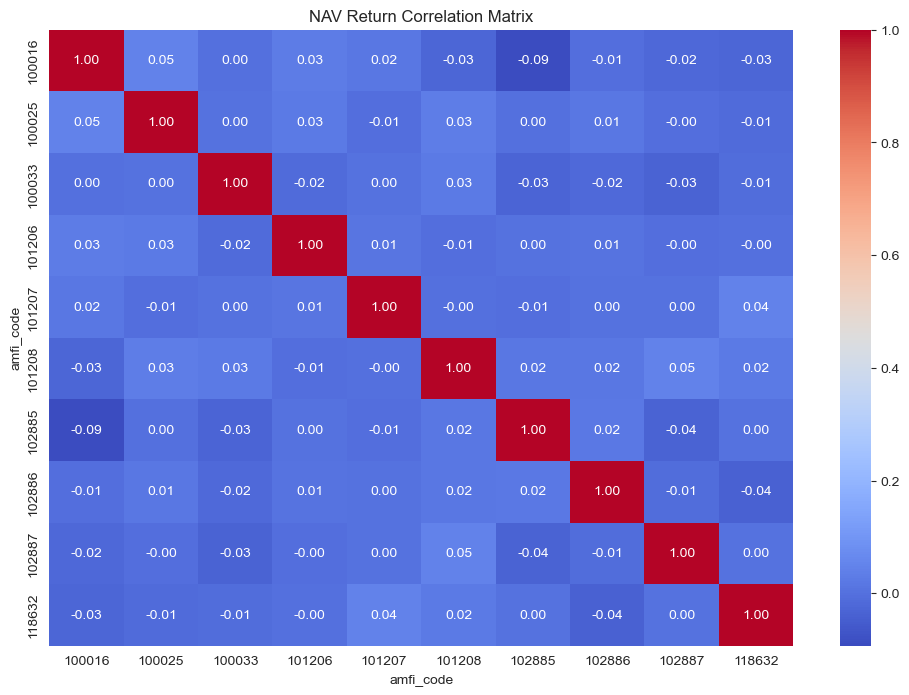

In [69]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'NAV Return Correlation Matrix'
)
plt.savefig(
    "exported_charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observations

- Most equity-oriented funds display positive correlation.
- Some funds exhibit stronger relationships due to similar investment strategies.
- Lower correlations may indicate diversification opportunities.
- Correlation analysis helps investors construct balanced portfolios.

## Average Correlation by Fund

The following chart compares the average correlation of each selected scheme with the rest of the portfolio.

In [70]:
avg_corr = (
    corr_matrix.mean()
    .sort_values(ascending=False)
)

avg_corr

amfi_code
101208    0.111976
100025    0.109801
101207    0.106659
101206    0.104588
102886    0.099146
118632    0.098001
102887    0.094287
100033    0.091949
100016    0.091408
102885    0.087716
dtype: float64

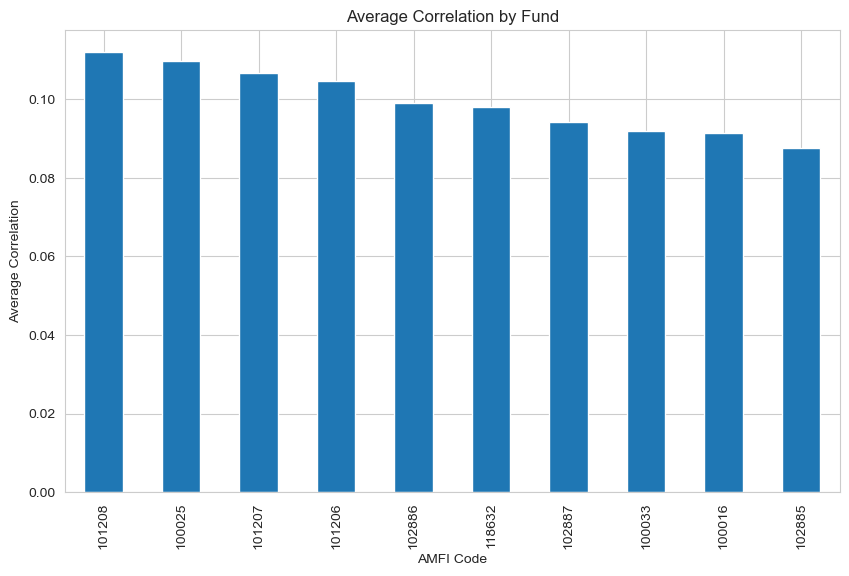

In [71]:
plt.figure(figsize=(10,6))

avg_corr.plot(
    kind='bar'
)

plt.title(
    'Average Correlation by Fund'
)

plt.xlabel('AMFI Code')

plt.ylabel('Average Correlation')
plt.savefig(
    "exported_charts/average_fund_correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Key Insight

The selected mutual fund schemes exhibit generally positive correlations, reflecting common exposure to overall market movements. However, differences in correlation levels suggest that diversification benefits can still be achieved through careful fund selection.

In [72]:
print(nav.shape)
print(nav['amfi_code'].nunique())

(46000, 3)
40


# 9. Sector Allocation Analysis

## Objective

Sector allocation analysis helps identify where mutual fund managers are allocating capital across the economy.

By aggregating portfolio holdings across all equity funds, we can determine which sectors receive the highest portfolio exposure and understand the concentration of investments across industries.

In [73]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [74]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [75]:
sector_weights = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_weights.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


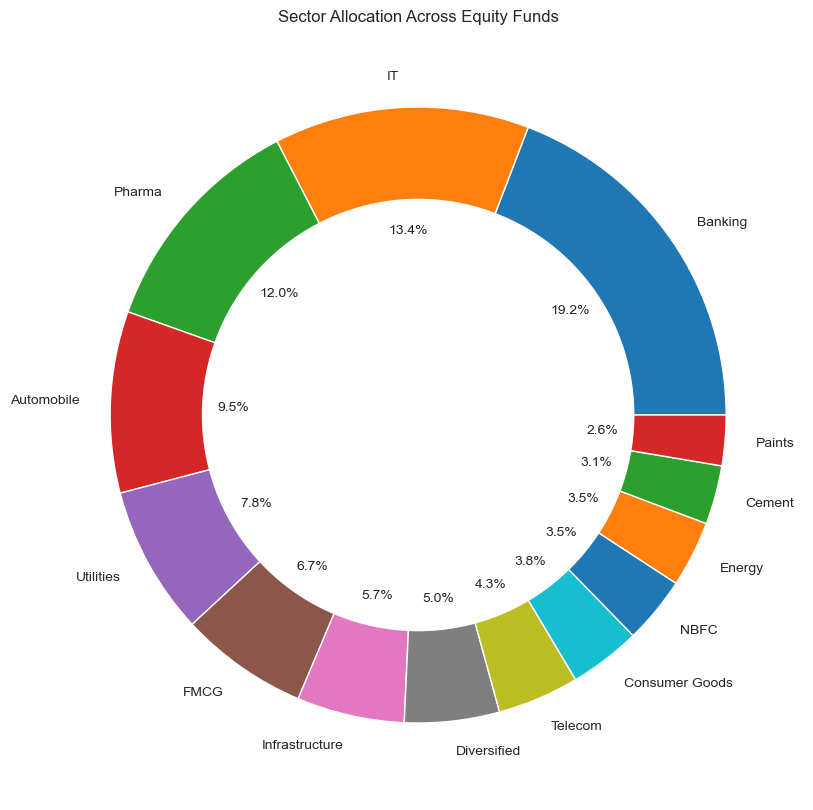

In [76]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights['weight_pct'],
    labels=sector_weights['sector'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')
plt.savefig(
    "exported_charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observations

- Portfolio allocation is concentrated across a limited number of sectors.
- Some sectors receive significantly higher exposure compared to others.
- Sector concentration reflects the investment preferences of fund managers.
- Diversification across sectors helps reduce portfolio-specific risks.

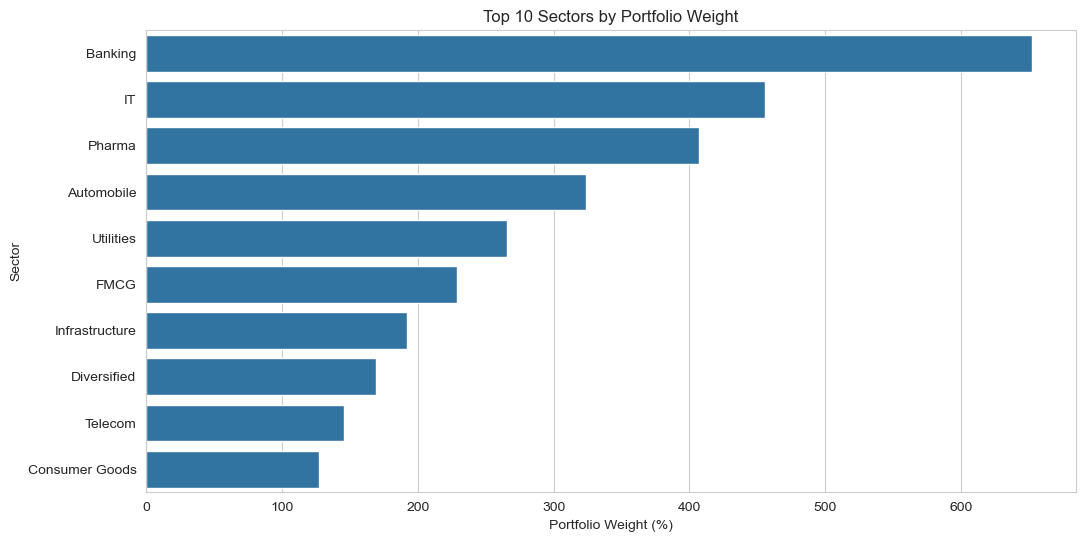

In [77]:
top_sectors = (
    sector_weights.head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sectors,
    x='weight_pct',
    y='sector'
)

plt.title('Top 10 Sectors by Portfolio Weight')

plt.xlabel('Portfolio Weight (%)')

plt.ylabel('Sector')
plt.savefig(
    "exported_charts/top_10_sectors.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key Insight

A significant portion of portfolio allocation is concentrated in a few dominant sectors, indicating strong conviction among fund managers toward specific areas of the economy. Sector allocation patterns provide insight into prevailing investment themes and market expectations.

# 10. Key EDA Findings

## Objective

The following findings summarize the most significant insights derived from the exploratory data analysis of mutual fund industry datasets from 2022 to 2025.

Each finding is supported by the corresponding visualization generated in this notebook.

### Finding 1

Daily NAV values across mutual fund schemes exhibited a strong upward trend during the 2023 bull market period, reflecting favorable market conditions and positive investor sentiment.

**Reference:** NAV Trend Analysis

### Finding 2

Several schemes experienced temporary declines in NAV during the 2024 market correction, highlighting the impact of market volatility on fund performance.

**Reference:** NAV Trend Analysis

### Finding 3

SBI Mutual Fund maintained the highest Assets Under Management among all fund houses and demonstrated clear dominance in the Indian mutual fund industry.

**Reference:** AUM Growth Analysis

### Finding 4

Monthly SIP inflows increased steadily throughout the study period and reached a record high of approximately ₹31,002 crore in December 2025.

**Reference:** SIP Inflow Trend Analysis

### Finding 5

Investor inflows were concentrated in a limited number of mutual fund categories, indicating strong category preferences among investors.

**Reference:** Category Inflow Heatmap

### Finding 6

Working-age investors accounted for the largest proportion of mutual fund participation, demonstrating strong adoption among economically active age groups.

**Reference:** Investor Age Group Distribution

### Finding 7

Average investment amounts remained relatively similar across age groups, suggesting broadly consistent investment behaviour among investors.

**Reference:** SIP Amount by Age Group

### Finding 8

A limited number of states contributed a significant share of total SIP investments, indicating geographic concentration in investment activity.

**Reference:** State-wise SIP Investment Analysis

### Finding 9

Total mutual fund folios increased from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting substantial growth in investor participation.

**Reference:** Folio Growth Analysis

### Finding 10

Portfolio allocations were concentrated in a few dominant sectors, indicating strong conviction among fund managers toward specific areas of the economy.

**Reference:** Sector Allocation Analysis

## Conclusion

The exploratory data analysis highlights strong growth in the Indian mutual fund industry between 2022 and 2025. Rising SIP participation, increasing folio counts, expanding Assets Under Management, and broad investor engagement collectively indicate growing investor confidence and continued industry expansion.

# 11. Exporting Charts for Final Report

## Objective

The charts generated throughout this notebook can be exported as PNG files for inclusion in the final project report and presentation.

High-priority visualizations include NAV trends, AUM growth, SIP inflows, category inflow heatmaps, investor demographics, folio growth, correlation matrices, and sector allocation charts.

In [78]:
import os

os.makedirs("exported_charts", exist_ok=True)

print("Folder created successfully.")

Folder created successfully.
